In [81]:
# Starter imports

import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

# Import Data

from pybaseball import statcast 

**Research Question**: How can pitch-level characteristics and in-game context at the moment of pitch release be used to predict whether a batter will swing or take a pitch in MLB games?

The improtance of this is that predicting whether a batter will swing or take a pitch is crucial for improving pitching strategies and hitting analysis, as it allows teams to tailor their tactics based on the batter's behavior. Accurate predictions can lead to smart in-game decisions, such as pitch selection. This resarch contributs to advanced sports analytics, helping coaches and teams optimize player performance.

**Hypothesis:** We hypothesize that pitch-level characteristics, including pitch type, velocity, movement, and location, along with in-game context such as count, score, and batter-pitcher handedness, are significant predictors of whether a batter will swing or take a pitch in MLB games. In particular, batters are more likely to swing at pitches with higher velocities, pitches located in the strike zone, and during hitter-friendly counts (such as 3-1 or 2-0). This prediction is based on the belief that these factors reflect both the batter’s swing tendencies and their ability to assess pitches quickly, which is crucial in making split-second decisions during live at-bats.

**The statcast dataset has over a million rows, so we will have this dataset filtered to the June of the 2024 MLB Season!**

In [82]:
june_statcast_2024 = pd.read_csv("june_statcast_2024.csv")

june_statcast_2024.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2024-06-30,82.4,-3.63,4.42,"Sewald, Paul",680869,623149,strikeout,called_strike,...,2.0,2.68,-1.28,-1.28,15.8,NaN,NaN,NaN,NaN,NaN
1,ST,2024-06-30,82.2,-3.70,4.35,"Sewald, Paul",680869,623149,NaN,foul,...,2.0,2.78,-1.26,-1.26,16.6,19.691472,-13.003297,35.999290,42.538496,37.741756
2,FF,2024-06-30,90.8,-3.55,4.54,"Sewald, Paul",680869,623149,NaN,foul,...,2.0,1.50,0.81,0.81,16.6,14.876329,3.342341,30.357166,37.709934,27.167091
3,ST,2024-06-30,83.4,-3.64,4.40,"Sewald, Paul",680869,623149,NaN,ball,...,2.0,2.49,-1.45,-1.45,15.3,NaN,NaN,NaN,NaN,NaN
4,FF,2024-06-30,89.9,-3.53,4.45,"Sewald, Paul",680869,623149,NaN,foul,...,2.0,1.86,0.68,0.68,19.2,10.061360,12.153604,30.257349,43.514080,22.018539


**Let's start with some basic statistics on our dataset.**

In [83]:
june_statcast_2024.describe()

,release_speed,release_pos_x,release_pos_z,batter,pitcher,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
count,115953.000000,115953.000000,115953.000000,116355.000000,116355.000000,0.0,0.0,0.0,0.0,115939.000000,...,116012.000000,115948.000000,115953.000000,115953.000000,114963.000000,53570.000000,53570.000000,53569.000000,53525.000000,53525.000000
mean,89.255297,-0.804447,5.757763,640943.322247,638099.830158,NaN,NaN,NaN,NaN,9.024108,...,1.712943,2.319999,0.324320,-0.107056,38.117908,9.255037,-0.854756,32.227414,37.099818,29.875902
std,6.024125,1.881957,0.527013,51393.908377,53600.189628,NaN,NaN,NaN,NaN,4.238485,...,3.796852,1.060860,0.834605,0.888982,12.929079,11.734485,20.370954,7.121973,7.242480,11.519003
min,31.900000,-4.680000,0.900000,444482.000000,434378.000000,NaN,NaN,NaN,NaN,1.000000,...,0.000000,0.270000,-2.200000,-2.200000,-70.100000,-88.324284,-179.136062,0.716620,8.911645,-11.977734
25%,84.900000,-2.120000,5.480000,621439.000000,607625.000000,NaN,NaN,NaN,NaN,5.000000,...,1.000000,1.400000,-0.320000,-0.860000,30.700000,2.045458,-12.944849,27.604088,32.130369,22.065354
50%,90.300000,-1.510000,5.800000,663728.000000,657508.000000,NaN,NaN,NaN,NaN,11.000000,...,1.000000,2.220000,0.500000,-0.210000,39.300000,9.597252,-0.071518,32.255026,37.080719,29.175451
75%,94.100000,0.920000,6.080000,671732.000000,671106.000000,NaN,NaN,NaN,NaN,13.000000,...,2.000000,2.990000,1.030000,0.640000,46.300000,17.004246,12.049693,36.893366,42.050658,37.357799
max,104.000000,4.550000,7.520000,807799.000000,814005.000000,NaN,NaN,NaN,NaN,14.000000,...,111.000000,24.050000,1.970000,2.090000,82.300000,80.892151,179.449388,88.124009,70.730504,71.731541


In [84]:
june_statcast_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116355 entries, 0 to 116354
Columns: 118 entries, pitch_type to intercept_ball_minus_batter_pos_y_inches
dtypes: float64(67), int64(34), object(17)
memory usage: 104.8+ MB


Before we start, we have to remove unrealistic pitch velocities. This is because (fill in later)

In [85]:
june_statcast_2024["release_speed"].describe()

count    115953.000000
mean         89.255297
std           6.024125
min          31.900000
25%          84.900000
50%          90.300000
75%          94.100000
max         104.000000
Name: release_speed, dtype: float64

In [86]:
june_statcast_2024 = june_statcast_2024[june_statcast_2024["release_speed"] >= 70]
june_statcast_2024["release_speed"].describe()

count    115741.000000
mean         89.315779
std           5.843874
min          70.000000
25%          84.900000
50%          90.300000
75%          94.100000
max         104.000000
Name: release_speed, dtype: float64

For our research problem, we want to create a target variable that represents what we are trying to predict. We wnat to know whether the batter will swing or not! The column `type` tells us what happened on the pitch and "S" indicates a swing, so we convert this into a binary variable where: `1 = swing` & `0 = take (ball)`!

In [87]:
june_statcast_2024["y_swing"] = (june_statcast_2024["type"] == "S").astype(int)
june_statcast_2024["y_swing"]

0         1
1         1
2         1
3         0
4         1
         ..
116350    1
116351    0
116352    0
116353    0
116354    0
Name: y_swing, Length: 115741, dtype: int64

Let's check how many swings & takes (balls) that we have in the dataset. We'll now calculate the proportions, which helps us understand whether the data is balanced or skewed! The dataset is fairly balanced, as both classes occur as similar rates. This is good bcause it makes the prediction task more reliable!

In [88]:
june_statcast_2024["y_swing"].value_counts(normalize=True)

y_swing
0    0.532145
1    0.467855
Name: proportion, dtype: float64

An interesting to explore is the swing behavior count. This is important because we want to see how the game situation affects a batter's decision!

In [89]:
june_statcast_2024.groupby(["balls", "strikes"])["y_swing"].mean().unstack()

strikes,0,1,2
balls,,,
0,0.511197,0.426064,0.376170
1,0.506980,0.454210,0.405489
2,0.537790,0.483574,0.450234
3,0.624400,0.500000,0.483714


Through this exploration, swing probability varies significantly with count, increasing with the number of balls and decreasing with the number of strikes, indicating that in-game context does play a role in the batter's decision making.

Let's now analyze pitch location!

For someone that is not into baseball as much, the plate_x represents how far the pitch is from the center of home plate horizontally. A value of 0 means that the pitch crossed the exact middle of the plate, negative values are inside to a right-handed batter, and positive values are outside. On the other hand, plate_z represents the height of the pitch as it crosses the plate, measured in feet from the ground. The strike zone is typically 1.5 to 3.5 feet high, depending on the batter, so values in that range are "hittable" pitches.

In [90]:
june_statcast_2024[["plate_x", "plate_z"]].describe()

,plate_x,plate_z
count,115728.000000,115728.000000
mean,0.060258,2.312306
std,0.842155,0.962462
min,-5.363822,-3.076603
25%,-0.503360,1.685628
50%,0.057758,2.317759
75%,0.621113,2.948307
max,4.888425,12.358563


This describes whre pitches are located across the plate. On average, pitches are centered horizontally (w/ a mean `plate_x` = 0.06) and around mid-height in the strike zone (mean `plate_z` = 2.31), which is expected since most pitches are thrown nar the zone. The spread (standard deviation) shows that there is meaningful variation, meaning batter wil see pitches both inside and outside the strike zone. The minimum and maximum values indicate some extreme pitches far outside the zone, which are important for understanding when batters choose not to swing.

Let's now take a sample of our data to plot the strike zone!

In [91]:
sample = june_statcast_2024.sample(5000, random_state=42)

The swings (orange) are heavily concentrated around the middle of the strike zone, especially near the center of the plate where pitches are easiest to hit. Most pitches fall roughly between about -1.5 and 1.5, which corresponds to the width of the strike zone and just beyond it. Takes are more spread out and dominate the edges of th zone and outside areas where pitches are harder or riskier to hit. There is a clear overlap region in the middle, which represents borderline pitches where the batter's decision is less consistent. Pitch location is a strong predictor of swing decisions, but not perfectly deterministic. 

In the graph, swings (orange) are concentrated mostly inside this central rectangle — roughly between -1 and 1 on plate_x and between 1.5 and 3.5 on plate_z. Takes (blue) are more common outside this region, especially on pitches low, high, or far to the sides. This shows that batters are most likely to swing when pitches are in the strike zone and more likely to take when they are outside of it.

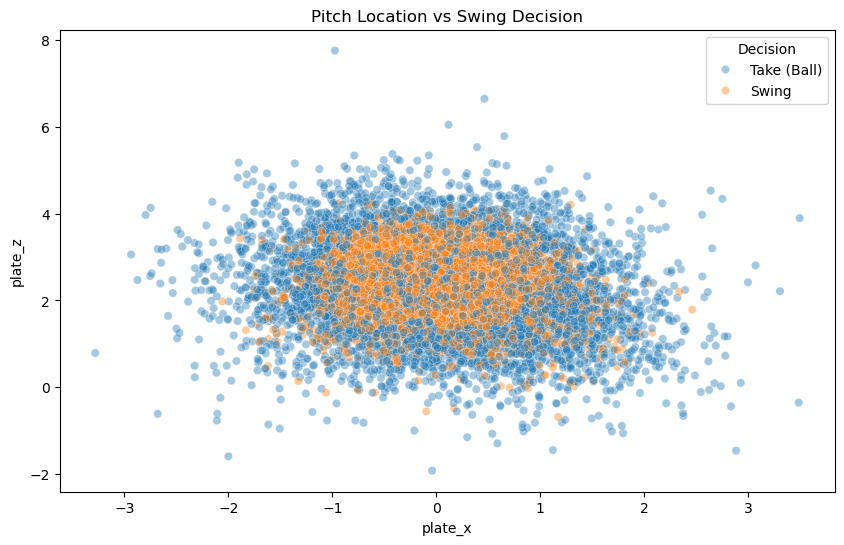

In [138]:
sample["swing_label"] = sample["y_swing"].map({0: "Take (Ball)", 1: "Swing"})


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample,
    x="plate_x",
    y="plate_z",
    hue="swing_label",
    alpha=0.4
)

plt.title("Pitch Location vs Swing Decision")
plt.legend(title="Decision");

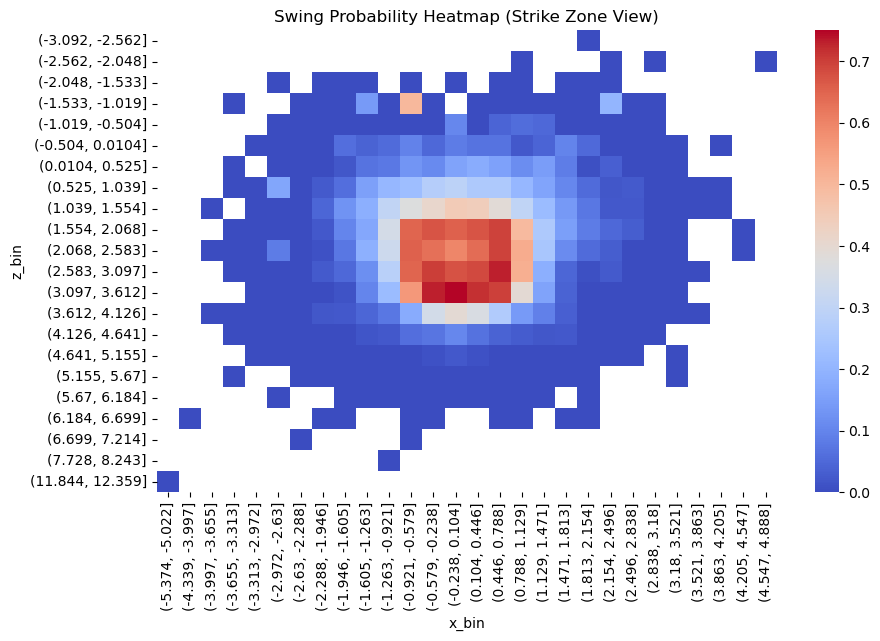

In [137]:
june_statcast_2024["x_bin"] = pd.cut(june_statcast_2024["plate_x"], bins=30)
june_statcast_2024["z_bin"] = pd.cut(june_statcast_2024["plate_z"], bins=30)

heat = june_statcast_2024.pivot_table(
    index="z_bin",
    columns="x_bin",
    values="y_swing",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(10, 6))

sns.heatmap(heat, cmap="coolwarm")

plt.title("Swing Probability Heatmap (Strike Zone View)")

plt.show()

Let's now analyze swing rate at each pitch type. Different pitch types (fastballs, sliders, changeups) are designed to deceive hitters in different ways, so swing behavior should vary across them. This helps us see whether pitch identity is predictive, which informs feature importance for our model.

In [94]:
pitch_swing = june_statcast_2024.groupby("pitch_name")["y_swing"].mean().sort_values(ascending=False)
pitch_swing

pitch_name
Slow Curve         1.000000
4-Seam Fastball    0.495506
Cutter             0.475864
Knuckle Curve      0.470191
Curveball          0.470155
Sweeper            0.467900
Slider             0.462382
Sinker             0.460899
Knuckleball        0.449219
Slurve             0.439560
Changeup           0.410736
Split-Finger       0.408696
Forkball           0.400000
Other              0.400000
Pitch Out          0.000000
Name: y_swing, dtype: float64

**To analyze this further: Let's put it into a graph!** 

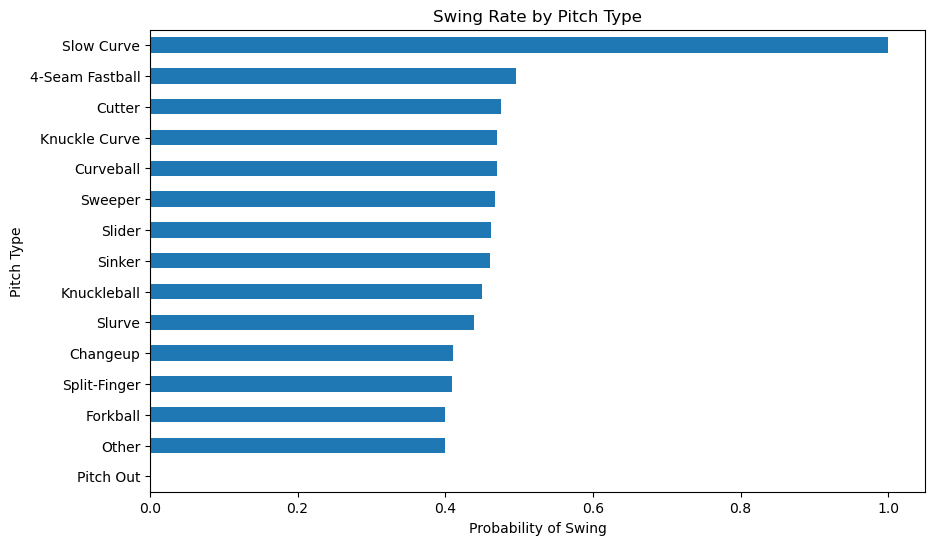

In [135]:
plt.figure(figsize=(10, 6))
june_statcast_2024.groupby("pitch_name")["y_swing"].mean().sort_values().plot(kind="barh")

plt.title("Swing Rate by Pitch Type")
plt.xlabel("Probability of Swing")
plt.ylabel("Pitch Type");

Batters are more likely to swing at faster and more standard pitches like a 4-seam fastball, while slower or more deceptive pitches lead to fewer strings. Even more extreme offspeed pitches such as eephus and slow curves tend to have very low swing rates, showing that deception and timing disruptuon reduce aggrssion.

Now, let's see if pitch velocity drives swing decisions.

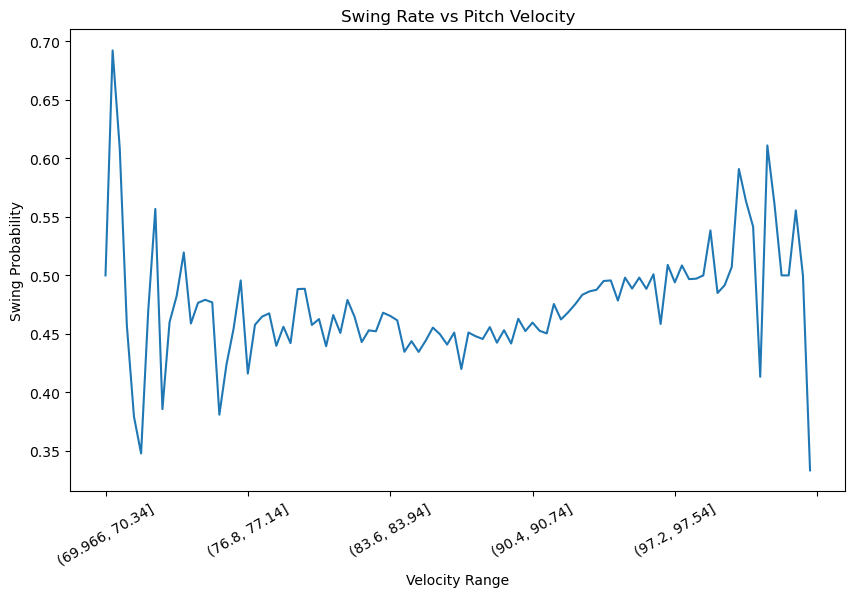

In [126]:
bin_edges = pd.cut(june_statcast_2024["release_speed"], bins=100)

plt.figure(figsize=(10, 6))

june_statcast_2024.groupby(bin_edges, observed=False)["y_swing"].mean().plot()
plt.xticks(rotation=30)
plt.title("Swing Rate vs Pitch Velocity")   
plt.xlabel("Velocity Range")
plt.ylabel("Swing Probability");

This line plot shows how swing probaiblities varies with pitch velocity. We see a significant spike in swing probability at very low velocities. For typical MLB fastball velocities, the swing probability remains fairly consistent around 0.45 to 0.55. At higher velocities, swing probability starts to increas again, likely due to the difficulty of laying off very fast pitches, forcing batters to swing more often. However, insanely fast pitches, we tend to see a noticeable decrease in swing probability.

Next, we'll analyze the swing rate based on the **handedness** of both the batter and pitcher to se if there's a pattern in swing behavior that depends on which hand the or pitcher uses.

In [117]:
handedness_swing_rate = june_statcast_2024.groupby(["stand", "p_throws"])["y_swing"].mean()
handedness_swing_rate

stand  p_throws
L      L           0.468977
       R           0.465426
R      L           0.459669
       R           0.473977
Name: y_swing, dtype: float64

Let's plot this to see how it fares!

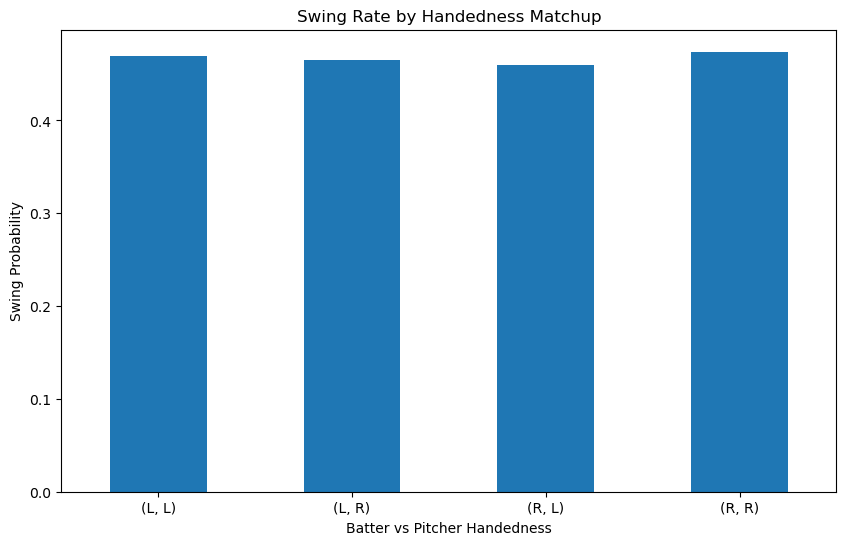

In [ ]:
handedness_swing_rate.plot(kind="bar", figsize=(10, 6))
plt.title("Swing Rate by Handedness Matchup")
plt.xlabel("Batter vs Pitcher Handedness")
plt.ylabel("Swing Probability")
plt.show()

The swing probabilities for the different handedness matchups are very similar, ranging from 0.46 to 0.47. Left-handed batters facing either left-handed or right-handed pitchers have nearly identical swing rates (~0.47), while right-handed batters show a slight decrease in swing probability when facing left-handed pitchers (~0.46). Overall, there is no strong platoon advantage in terms of swing behavior based on pitcher-batter handedness.